In [1]:
import os
import shutil

# 直接指定完整路径删除
cache_path = r"C:\Users\高伽里\scikit_learn_data"

# 删除整个 scikit_learn_data 文件夹
if os.path.exists(cache_path):
    shutil.rmtree(cache_path)
    print("✅ 缓存删除成功")
else:
    print("文件夹不存在，跳过")

✅ 缓存删除成功


In [2]:
#数据导入及处理缺失值
#Data import and handling of missing values
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing

# 加载数据
# load data
data = fetch_california_housing()

X = data.data          # 特征值eigenvalue
y = data.target        # 目标值（房价）Target value (house price)

feature_names = data.feature_names

# Transfer to DataFrame（推荐，方便后续操作）
X = pd.DataFrame(X, columns=feature_names)
y = pd.Series(y, name="MedHouseVal")

print(X.head())
print(y.head())
print("Shape of X:", X.shape)

# ===== 处理缺失值 =====
#Handling Missing Values
print("Missing values before cleaning:")
print(X.isnull().sum())

# 删除含缺失值的行（如果有）
# Delete rows with missing values (if any).
X = X.dropna()
y = y.loc[X.index]   # 保持 X 和 y 对齐 Align X and Y

print("Shape after removing missing values:", X.shape)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64
Shape of X: (20640, 8)
Missing values before cleaning:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64
Shape after removing missing values: (20640, 8)


In [3]:
#Baseline Modal
#Data preprocessing and division of training，validation and test set
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# 先从X特征值，y房价 中分出 test 和 train_val两个数据集
# First, separate the "X feature values" and "y house prices" into two datasets: "test" and "train_val".
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=26
)
# X_train_val → 80% 的特征，X_test → 20% 的特征，y_train_val → 80% 的标签，y_test → 20% 的标签
# X_train_val → 80% of the features, X_test → 20% of the features, 
# y_train_val → 80% of the labels, y_test → 20% of the labels

# 从X_train_val, y_train_val里再分 validation（分成X_train, X_val, y_train, y_val）
# From X_train_val and y_train_val, further divide into validation (resulting in X_train, X_val, y_train, y_val)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1, random_state=26
)#这里的0.1是train_val80%里的10%
#Here, 0.1 refers to the 10% within the "train_val 80%" portion.


# 在标准化前，先保存 raw（未标准化）版本：后面kNN需要用原始经纬度
# Before standardization, save the raw (unstandardized) version first: 
# the kNN algorithm later will require the original latitude and longitude values.
X_train_raw = X_train.copy()
X_val_raw   = X_val.copy()
X_test_raw  = X_test.copy()

# scale (fit only on train) and then convert it back to a DataFrame#标准化（只在训练集）并转回DataFrame
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns,index=X_train_raw.index)
X_val   = pd.DataFrame(scaler.transform(X_val), columns=X.columns,index=X_val_raw.index)
X_test  = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test_raw.index)
#scaler.transform 标准化 test 数据 means to Standardized test data
#index=X_test_raw.index Pandas 会默认生成新的 0~n 索引 Pandas will automatically generate new indices ranging from 0 to n.
#Add index=...，这样索引不会乱（对齐 y / 后面 debug 更稳）so the index won't be disordered (it will be more stable when aligning y / and then the debug part).

In [4]:
# Model 2: Add neighbourhood-based features

from sklearn.neighbors import NearestNeighbors

K = 7  # Number of nearest neighbours used to construct neighbourhood features


#   Fit kNN using training coordinates only, this ensures neighbourhood features are constructed 
#   solely from training data and avoids data leakage.
knn = NearestNeighbors(n_neighbors=K + 1)
knn.fit(X_train_raw[['Latitude', 'Longitude']])

# Align y_train with X_train_raw so neighbour indices correctly map to prices
y_train_aligned = y_train.loc[X_train_raw.index].to_numpy()



# Define a function to compute neighbourhood price statistics
#这部分是用来计算第一个图所需要的数据
def neighbour_summary_feature(query_df, summary="mean", exclude_self=False):
    # Find nearest neighbours based on geographic coordinates
    _, inds = knn.kneighbors(query_df[['Latitude', 'Longitude']])

    values = []

    # Loop through each sample and compute the summary statistic
    for row_i, idxs in enumerate(inds):

        if exclude_self:
            # Remove the sample itself if it appears in neighbours
            idxs = idxs[idxs != row_i]

            # Keep exactly K neighbours
            idxs = idxs[:K]

        else:
            # Validation/test samples are not part of training set
            # so we directly take the first K neighbours
            idxs = idxs[:K]

        # Retrieve neighbour prices
        neigh_prices = y_train_aligned[idxs]

        if summary == "mean":
            values.append(np.mean(neigh_prices))

        elif summary == "median":
            values.append(np.median(neigh_prices))

        elif summary == "min":
            values.append(np.min(neigh_prices))

        elif summary == "max":
            values.append(np.max(neigh_prices))

        elif summary == "range":
            values.append(np.max(neigh_prices) - np.min(neigh_prices))

        else:
            raise ValueError("summary must be one of: mean, median, min, max, range")

    return np.array(values)



# Neighbourhood mean price / 邻域平均房价
neigh_price_mean_train = neighbour_summary_feature(X_train_raw, summary="mean", exclude_self=True)
neigh_price_mean_val   = neighbour_summary_feature(X_val_raw, summary="mean", exclude_self=False)
neigh_price_mean_test  = neighbour_summary_feature(X_test_raw, summary="mean", exclude_self=False)

# Neighbourhood median price / 邻域房价中位数
neigh_price_median_train = neighbour_summary_feature(X_train_raw, summary="median", exclude_self=True)
neigh_price_median_val   = neighbour_summary_feature(X_val_raw, summary="median", exclude_self=False)
neigh_price_median_test  = neighbour_summary_feature(X_test_raw, summary="median", exclude_self=False)

# Neighbourhood minimum price / 邻域最低房价
neigh_price_min_train = neighbour_summary_feature(X_train_raw, summary="min", exclude_self=True)
neigh_price_min_val   = neighbour_summary_feature(X_val_raw, summary="min", exclude_self=False)
neigh_price_min_test  = neighbour_summary_feature(X_test_raw, summary="min", exclude_self=False)

# Neighbourhood maximum price / 邻域最高房价
neigh_price_max_train = neighbour_summary_feature(X_train_raw, summary="max", exclude_self=True)
neigh_price_max_val   = neighbour_summary_feature(X_val_raw, summary="max", exclude_self=False)
neigh_price_max_test  = neighbour_summary_feature(X_test_raw, summary="max", exclude_self=False)

# Neighbourhood price range / 邻域房价极差
neigh_price_range_train = neighbour_summary_feature(X_train_raw, summary="range", exclude_self=True)
neigh_price_range_val   = neighbour_summary_feature(X_val_raw, summary="range", exclude_self=False)
neigh_price_range_test  = neighbour_summary_feature(X_test_raw, summary="range", exclude_self=False)




### 用于计算合并之前的baseline validation MSE的函数
#后面用到的baseline model都是这个，就不用繁琐的每次都写了
scaler_base = StandardScaler()

X_train_base = scaler_base.fit_transform(X_train_raw)
X_val_base = scaler_base.transform(X_val_raw)

baseline_model = MLPRegressor(
    hidden_layer_sizes=(128, 32),
    activation='tanh',
    solver='adam',
    learning_rate_init=1e-3,
    max_iter=800,
    early_stopping=False,
    random_state=26
)

#计算后续需要的baseline validation MSE
baseline_model.fit(X_train_base, y_train)
baseline_val_pred = baseline_model.predict(X_val_base)
baseline_val_mse = mean_squared_error(y_val, baseline_val_pred)


  Model 1 — Baseline
  Train MSE : 0.22
  Val   MSE : 0.28
  Val/Train : 1.248
  ✓ Diagnosis : GOOD FIT     — train and val MSE are close
  ✓ 诊断结果  : 拟合良好 — 训练集与验证集误差接近

  Model 2 — With Neighbourhood Features
  Train MSE : 0.10
  Val   MSE : 0.27
  Val/Train : 2.822
  ⚠ Diagnosis : OVERFITTING  — val MSE is much larger than train MSE
  ⚠ 诊断结果  : 过拟合 — 验证集误差远大于训练集误差


C:\Users\高伽里\AppData\Local\Temp\ipykernel_28088\1698260242.py:137: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from current font.
  plt.tight_layout()
C:\Users\高伽里\AppData\Local\Temp\ipykernel_28088\1698260242.py:137: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from current font.
  plt.tight_layout()
C:\Users\高伽里\AppData\Local\Temp\ipykernel_28088\1698260242.py:137: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from current font.
  plt.tight_layout()
C:\Users\高伽里\AppData\Local\Temp\ipykernel_28088\1698260242.py:137: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from current font.
  plt.tight_layout()
C:\Users\高伽里\AppData\Local\Temp\ipykernel_28088\1698260242.py:137: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from current font.
  plt.tight_layout()
C:\Users\高伽里\AppData\Local\Temp\ipykernel_28088\1698260242.py:137: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEOGRAPH-8BC1}) missing fr

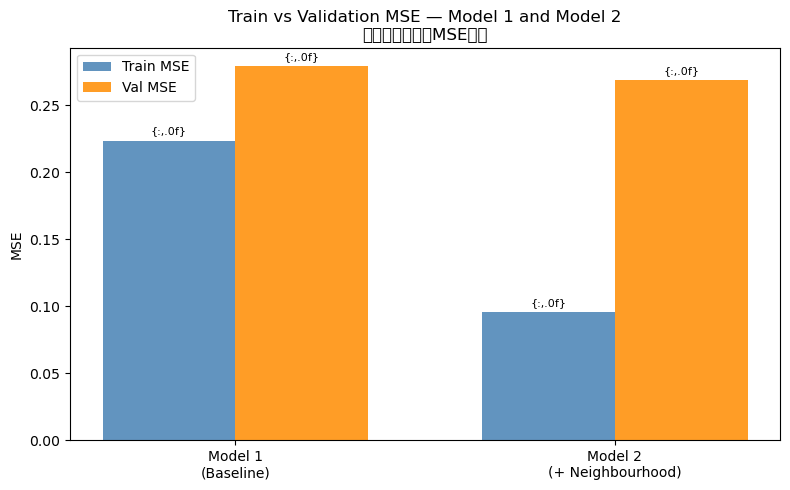


正在收集学习曲线数据（可能需要一点时间）…


c:\ProgramData\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# ============================================================
# Overfitting / Underfitting Check for Model 1 and Model 2
# 过拟合/欠拟合检查 — 模型1（基线）与模型2（含邻域特征）
# ============================================================

# ── Diagnosis helper / 诊断辅助函数 ──────────────────────────
import matplotlib.pyplot as plt  
def diagnose(model_name, train_mse, val_mse, threshold_ratio=1.5):
    """
    Print an overfitting/underfitting diagnosis based on Val/Train MSE ratio.
    根据验证集与训练集MSE比值，打印过拟合/欠拟合诊断结果。
    """
    # Compute ratio of validation MSE to training MSE
    # 计算验证集MSE与训练集MSE的比值
    ratio = val_mse / train_mse if train_mse > 0 else float('inf')

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Train MSE : {train_mse:,.2f}")
    print(f"  Val   MSE : {val_mse:,.2f}")
    print(f"  Val/Train : {ratio:.3f}")

    # Diagnosis rules / 诊断规则:
    # Train MSE very high             → Underfitting / 训练误差极高 → 欠拟合
    # Val/Train ratio > threshold     → Overfitting  / 比值过大     → 过拟合
    # Otherwise                       → Good fit     / 否则         → 拟合良好
    if train_mse > 1e10:
        print("  ⚠ Diagnosis : UNDERFITTING — training error is very high")
        print("  ⚠ 诊断结果  : 欠拟合 — 训练误差过高，模型未能有效学习")
    elif ratio > threshold_ratio:
        print("  ⚠ Diagnosis : OVERFITTING  — val MSE is much larger than train MSE")
        print("  ⚠ 诊断结果  : 过拟合 — 验证集误差远大于训练集误差")
    else:
        print("  ✓ Diagnosis : GOOD FIT     — train and val MSE are close")
        print("  ✓ 诊断结果  : 拟合良好 — 训练集与验证集误差接近")
    print(f"{'='*55}")


# ============================================================
# MODEL 1 — Baseline
# 模型1 — 基线模型
# Reuse scaler_base, X_train_base, X_val_base, baseline_model
# 直接复用你原代码中已定义的 scaler_base 和 baseline_model
# ============================================================

# baseline_model was already fitted on X_train_base earlier
# baseline_model 在前面已经用 X_train_base 训练完毕，直接预测即可
train_mse_m1 = mean_squared_error(y_train, baseline_model.predict(X_train_base))
val_mse_m1   = mean_squared_error(y_val,   baseline_model.predict(X_val_base))

diagnose("Model 1 — Baseline", train_mse_m1, val_mse_m1)


# ============================================================
# MODEL 2 — With all five neighbourhood features
# 模型2 — 包含全部五个邻域统计特征
# ============================================================

# Copy raw feature sets to avoid modifying original data
# 复制原始特征集，避免污染原有变量
X_train_m2 = X_train_raw.copy()
X_val_m2   = X_val_raw.copy()

# Append all five neighbourhood price statistics as new input features
# 将五个邻域房价统计值追加为新的输入特征列
X_train_m2['NeighbourPriceMean']   = neigh_price_mean_train
X_train_m2['NeighbourPriceMedian'] = neigh_price_median_train
X_train_m2['NeighbourPriceMin']    = neigh_price_min_train
X_train_m2['NeighbourPriceMax']    = neigh_price_max_train
X_train_m2['NeighbourPriceRange']  = neigh_price_range_train

X_val_m2['NeighbourPriceMean']     = neigh_price_mean_val
X_val_m2['NeighbourPriceMedian']   = neigh_price_median_val
X_val_m2['NeighbourPriceMin']      = neigh_price_min_val
X_val_m2['NeighbourPriceMax']      = neigh_price_max_val
X_val_m2['NeighbourPriceRange']    = neigh_price_range_val

# Re-standardise after adding new features
# Scaler is fitted only on training set to avoid data leakage
# 加入新特征后重新标准化，scaler仅在训练集上拟合以避免数据泄露
scaler_m2    = StandardScaler()
X_train_m2_s = scaler_m2.fit_transform(X_train_m2)
X_val_m2_s   = scaler_m2.transform(X_val_m2)

# Train Model 2 using the same architecture as the baseline for fair comparison
# 使用与基线模型完全相同的架构训练模型2，保证对比公平
model2 = MLPRegressor(
    hidden_layer_sizes=(128, 32),
    activation='tanh',
    solver='adam',
    learning_rate_init=1e-3,
    max_iter=800,
    early_stopping=False,
    random_state=26
)
model2.fit(X_train_m2_s, y_train)

# Compute MSE on both training and validation sets
# 分别在训练集和验证集上计算MSE
train_mse_m2 = mean_squared_error(y_train, model2.predict(X_train_m2_s))
val_mse_m2   = mean_squared_error(y_val,   model2.predict(X_val_m2_s))

diagnose("Model 2 — With Neighbourhood Features", train_mse_m2, val_mse_m2)


# ============================================================
# VISUALISATION 1 — Bar chart: Train vs Val MSE
# 可视化1 — 柱状图：训练集与验证集MSE对比
# ============================================================

labels     = ['Model 1\n(Baseline)', 'Model 2\n(+ Neighbourhood)']
train_mses = [train_mse_m1, train_mse_m2]
val_mses   = [val_mse_m1,   val_mse_m2]

x     = np.arange(len(labels))  # X-axis positions / x轴位置
width = 0.35                     # Bar width / 柱子宽度

fig, ax = plt.subplots(figsize=(8, 5))

# Plot train and val MSE bars side by side
# 并排绘制训练集和验证集MSE柱子
bars1 = ax.bar(x - width/2, train_mses, width, label='Train MSE', color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + width/2, val_mses,   width, label='Val MSE',   color='darkorange', alpha=0.85)

ax.set_ylabel('MSE')
ax.set_title('Train vs Validation MSE — Model 1 and Model 2\n训练集与验证集MSE对比')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Annotate each bar with its exact value
# 在柱子顶部标注具体数值
ax.bar_label(bars1, fmt='{:,.0f}', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='{:,.0f}', padding=3, fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# VISUALISATION 2 — Learning curves (MSE vs Epoch)
# 可视化2 — 学习曲线（MSE随训练轮数变化）
#
# Uses warm_start=True to train one epoch at a time and
# record train/val MSE after each epoch.
# 使用 warm_start=True 逐epoch训练，每轮结束后记录MSE。
#
# How to interpret / 学习曲线解读:
#   Both lines fall and converge         → Good fit    两线下降并收敛    → 拟合良好
#   Val rises while Train keeps falling  → Overfitting 验证线上升训练线降 → 过拟合
#   Both lines stay high                 → Underfitting 两线居高不下      → 欠拟合
# ============================================================

def collect_loss_curve(X_tr, y_tr, X_va, y_va, max_iter=800):
    """
    Train epoch-by-epoch and record train/val MSE at each step.
    逐epoch训练并在每轮结束后记录训练集与验证集的MSE。
    """
    # warm_start=True lets the model continue from where it left off
    # warm_start=True 使模型在每次 fit 时从上次结束处继续训练，而非重新初始化
    model = MLPRegressor(
        hidden_layer_sizes=(128, 32),
        activation='tanh',
        solver='adam',
        learning_rate_init=1e-3,
        max_iter=1,         # Train exactly one epoch per call / 每次只训练一个epoch
        warm_start=True,    # Retain weights between calls / 保留上次训练权重
        early_stopping=False,
        random_state=26
    )
    train_losses, val_losses = [], []

    for _ in range(max_iter):
        model.fit(X_tr, y_tr)  # Continue training for one more epoch / 继续训练一个epoch

        # Record MSE after this epoch / 记录本epoch结束后的MSE
        train_losses.append(mean_squared_error(y_tr, model.predict(X_tr)))
        val_losses.append(mean_squared_error(y_va,   model.predict(X_va)))

    return train_losses, val_losses


print("\nCollecting learning curves (this may take a moment)…")
print("正在收集学习曲线数据（可能需要一点时间）…")

# Collect learning curves for both models
# 分别收集两个模型的学习曲线数据
lc_train_m1, lc_val_m1 = collect_loss_curve(X_train_base,  y_train, X_val_base,  y_val)
lc_train_m2, lc_val_m2 = collect_loss_curve(X_train_m2_s,  y_train, X_val_m2_s,  y_val)

# Plot side-by-side learning curves
# 并排绘制两个模型的学习曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, lc_tr, lc_va, title in zip(
    axes,
    [lc_train_m1, lc_train_m2],
    [lc_val_m1,   lc_val_m2],
    ['Model 1 — Baseline', 'Model 2 — + Neighbourhood Features']
):
    epochs = range(1, len(lc_tr) + 1)

    # Solid line = Train MSE, Dashed line = Val MSE
    # 实线 = 训练集MSE，虚线 = 验证集MSE
    ax.plot(epochs, lc_tr, label='Train MSE', color='steelblue')
    ax.plot(epochs, lc_va, label='Val MSE',   color='darkorange', linestyle='--')

    ax.set_title(title)
    ax.set_xlabel('Epoch / 训练轮数')
    ax.set_ylabel('MSE')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle(
    'Learning Curves — Overfitting / Underfitting Check\n学习曲线 — 过拟合/欠拟合检查',
    fontsize=13
)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Parameter Search: Compare Model 1 variants vs Model 2
# 参数搜索：逐一改变Model1参数，记录与Model2的Val MSE和Test MSE差值
# Each experiment changes only ONE parameter at a time
# 每次实验只改变一个参数，其余保持与基线一致
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import NearestNeighbors

# ── Fixed reference: Model 2 Val MSE and Test MSE
# ── 固定参考值：Model2的验证集和测试集MSE
model2_val_mse = val_mse_m2

# Build Model 2 test set using existing scaler_m2 and test neighbourhood features
# 用已有的 scaler_m2 和测试集邻域特征构建Model2测试集
X_test_m2 = X_test_raw.copy()
X_test_m2['NeighbourPriceMean']   = neigh_price_mean_test
X_test_m2['NeighbourPriceMedian'] = neigh_price_median_test
X_test_m2['NeighbourPriceMin']    = neigh_price_min_test
X_test_m2['NeighbourPriceMax']    = neigh_price_max_test
X_test_m2['NeighbourPriceRange']  = neigh_price_range_test

# Standardise using the already-fitted scaler_m2 from above
# 使用上方已拟合好的 scaler_m2 进行标准化，保持一致性
X_test_m2_s     = scaler_m2.transform(X_test_m2)
model2_test_mse = mean_squared_error(y_test, model2.predict(X_test_m2_s))

print(f"Model 2  Val MSE (reference) : {model2_val_mse:.4f}")
print(f"Model 2 Test MSE (reference) : {model2_test_mse:.4f}\n")


# ============================================================
# Helper: rebuild Model 2 features for a given K
# 辅助函数：根据给定K值重新构建Model2的邻域特征
# ============================================================
def build_model2_sets(k):
    """
    Recompute neighbourhood features with K neighbours.
    Return standardised (train, val, test) feature matrices for Model 2.
    用K个邻居重新计算邻域特征，返回标准化后的训练/验证/测试特征矩阵。
    """
    # Fit kNN on training coordinates only to avoid data leakage
    # 仅在训练集坐标上拟合kNN，避免数据泄露
    knn_k = NearestNeighbors(n_neighbors=k + 1)
    knn_k.fit(X_train_raw[['Latitude', 'Longitude']])
    y_tr = y_train.loc[X_train_raw.index].to_numpy()

    def _stat(qdf, stat, excl):
        """Compute one neighbourhood price statistic.
           计算一种邻域房价统计值。"""
        _, inds = knn_k.kneighbors(qdf[['Latitude', 'Longitude']])
        out = []
        for i, idx in enumerate(inds):
            idx = idx[idx != i][:k] if excl else idx[:k]
            p   = y_tr[idx]
            out.append({'mean'  : np.mean,
                        'median': np.median,
                        'min'   : np.min,
                        'max'   : np.max,
                        'range' : lambda x: np.max(x) - np.min(x)}[stat](p))
        return np.array(out)

    def _aug(raw_df, excl):
        """Append all five neighbourhood features to a raw feature DataFrame.
           将五个邻域特征追加到原始特征DataFrame中。"""
        df = raw_df.copy()
        for s in ['mean', 'median', 'min', 'max', 'range']:
            df[f'NeighbourPrice{s.capitalize()}'] = _stat(raw_df, s, excl)
        return df

    Xtr = _aug(X_train_raw, excl=True)
    Xva = _aug(X_val_raw,   excl=False)
    Xte = _aug(X_test_raw,  excl=False)

    # Standardise using train set only to avoid data leakage
    # 仅用训练集拟合scaler，避免数据泄露
    sc = StandardScaler()
    return sc.fit_transform(Xtr), sc.transform(Xva), sc.transform(Xte)


# ============================================================
# Helper: train one MLP variant, return (val_mse, test_mse, model)
# 辅助函数：训练一个MLP变体，返回 (验证集MSE, 测试集MSE, 模型)
# ============================================================
def train_variant(hidden_layers, activation, Xtr, Xva, Xte):
    """
    Train MLP with given architecture and return val MSE, test MSE, and model.
    用指定架构训练MLP，返回验证集MSE、测试集MSE和模型对象。
    """
    m = MLPRegressor(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        solver='adam',
        learning_rate_init=1e-3,
        max_iter=800,
        early_stopping=False,
        random_state=26
    )
    m.fit(Xtr, y_train)
    return (mean_squared_error(y_val,  m.predict(Xva)),
            mean_squared_error(y_test, m.predict(Xte)),
            m)


# ── Standardise baseline (Model 1) features once — no neighbourhood features
# ── 提前标准化基线特征（Model1不含邻域特征），后续实验直接复用
sc0  = StandardScaler()
Xtr0 = sc0.fit_transform(X_train_raw)
Xva0 = sc0.transform(X_val_raw)
Xte0 = sc0.transform(X_test_raw)

# ── Pre-build Model 2 feature sets for default K=7
# ── 提前构建默认K=7的Model2特征集，实验1和实验2复用
Xtr_m2_k7, Xva_m2_k7, Xte_m2_k7 = build_model2_sets(7)

all_results = []   # Stores all experiment records / 存储所有实验记录


# ============================================================
# EXPERIMENT 1 — Hidden layer structures
# 实验1 — 隐藏层结构（激活函数=tanh，K=7 固定不变）
# ============================================================
hidden_candidates = [
    (64,), (128,), (256,),
    (64, 32), (128, 32), (128, 64),
    (256, 128), (128, 64, 32),
]

print("=" * 65)
print("Experiment 1: Hidden Layer Structures / 实验1：隐藏层结构")
print("=" * 65)

for hl in hidden_candidates:
    # Model 1: vary hidden layers, no neighbourhood features
    # Model1：改变隐藏层结构，不含邻域特征
    m1_val, m1_test, _ = train_variant(hl, 'tanh', Xtr0, Xva0, Xte0)

    # Model 2: same hidden layers, with neighbourhood features (K=7)
    # Model2：相同隐藏层结构，含邻域特征（K=7）
    m2_val, m2_test, _ = train_variant(hl, 'tanh', Xtr_m2_k7, Xva_m2_k7, Xte_m2_k7)

    all_results.append({
        "Experiment"      : "Hidden Layers",
        "Parameter"       : str(hl),
        "M1 Val MSE"      : m1_val,
        "M2 Val MSE"      : m2_val,
        "Val Diff(M1-M2)" : m1_val - m2_val,
        "M1 Test MSE"     : m1_test,
        "M2 Test MSE"     : m2_test,
        "Test Diff(M1-M2)": m1_test - m2_test,
    })
    print(f"  {str(hl):<18}  "
          f"Val  M1={m1_val:.4f} M2={m2_val:.4f} Δ={m1_val-m2_val:+.4f}  |  "
          f"Test M1={m1_test:.4f} M2={m2_test:.4f} Δ={m1_test-m2_test:+.4f}")


# ============================================================
# EXPERIMENT 2 — Activation functions
# 实验2 — 激活函数（隐藏层=(128,32)，K=7 固定不变）
# ============================================================
activation_candidates = ['relu', 'tanh', 'logistic']

print("\n" + "=" * 65)
print("Experiment 2: Activation Functions / 实验2：激活函数")
print("=" * 65)

for act in activation_candidates:
    m1_val, m1_test, _ = train_variant((128, 32), act, Xtr0, Xva0, Xte0)
    m2_val, m2_test, _ = train_variant((128, 32), act, Xtr_m2_k7, Xva_m2_k7, Xte_m2_k7)

    all_results.append({
        "Experiment"      : "Activation",
        "Parameter"       : act,
        "M1 Val MSE"      : m1_val,
        "M2 Val MSE"      : m2_val,
        "Val Diff(M1-M2)" : m1_val - m2_val,
        "M1 Test MSE"     : m1_test,
        "M2 Test MSE"     : m2_test,
        "Test Diff(M1-M2)": m1_test - m2_test,
    })
    print(f"  {act:<18}  "
          f"Val  M1={m1_val:.4f} M2={m2_val:.4f} Δ={m1_val-m2_val:+.4f}  |  "
          f"Test M1={m1_test:.4f} M2={m2_test:.4f} Δ={m1_test-m2_test:+.4f}")


# ============================================================
# EXPERIMENT 3 — K values
# 实验3 — K值（隐藏层=(128,32)，激活函数=tanh 固定不变）
# ============================================================
k_candidates = [3, 5, 7, 10, 15, 20]

print("\n" + "=" * 65)
print("Experiment 3: K Values / 实验3：K值（邻居数量）")
print("=" * 65)

for k in k_candidates:
    # Model 1 never uses neighbourhood features → same Xtr0/Xva0/Xte0
    # Model1始终不含邻域特征，特征集不随K变化
    m1_val, m1_test, _ = train_variant((128, 32), 'tanh', Xtr0, Xva0, Xte0)

    # Model 2 uses neighbourhood features built with this K
    # Model2使用当前K值构建的邻域特征
    Xtr_k, Xva_k, Xte_k = build_model2_sets(k)
    m2_val, m2_test, _  = train_variant((128, 32), 'tanh', Xtr_k, Xva_k, Xte_k)

    all_results.append({
        "Experiment"      : "K Value",
        "Parameter"       : f"K={k}",
        "M1 Val MSE"      : m1_val,
        "M2 Val MSE"      : m2_val,
        "Val Diff(M1-M2)" : m1_val - m2_val,
        "M1 Test MSE"     : m1_test,
        "M2 Test MSE"     : m2_test,
        "Test Diff(M1-M2)": m1_test - m2_test,
    })
    print(f"  K={k:<16}  "
          f"Val  M1={m1_val:.4f} M2={m2_val:.4f} Δ={m1_val-m2_val:+.4f}  |  "
          f"Test M1={m1_test:.4f} M2={m2_test:.4f} Δ={m1_test-m2_test:+.4f}")


# ============================================================
# Summary table / 汇总表格
# ============================================================
results_df = pd.DataFrame(all_results)
print("\n\nFull Results / 完整结果")
print(results_df.to_string(index=False))

# Best config = largest Val Diff (most improvement from neighbourhood features)
# 最佳配置 = Val MSE差值最大（加入邻域特征后改善最多）的那组
best_val_row  = results_df.loc[results_df["Val Diff(M1-M2)"].idxmax()]
best_test_row = results_df.loc[results_df["Test Diff(M1-M2)"].idxmax()]

print(f"\nBest config by Val  MSE gap / 验证集MSE差值最大配置: "
      f"{best_val_row['Experiment']} = {best_val_row['Parameter']}  "
      f"Δ={best_val_row['Val Diff(M1-M2)']:+.4f}")
print(f"Best config by Test MSE gap / 测试集MSE差值最大配置: "
      f"{best_test_row['Experiment']} = {best_test_row['Parameter']}  "
      f"Δ={best_test_row['Test Diff(M1-M2)']:+.4f}")


# ============================================================
# FINAL SUMMARY CHART — 3 rows × 3 cols
# 最终汇总图 — 3行 × 3列
#   Row 1 / 第一行: Val  MSE bar chart (M1 vs M2) per experiment
#   Row 2 / 第二行: Test MSE bar chart (M1 vs M2) per experiment
#   Row 3 / 第三行: Diff line chart (Val & Test M1-M2) per experiment
# ============================================================
experiments = ["Hidden Layers", "Activation", "K Value"]
exp_labels  = {
    "Hidden Layers": "Hidden Layers / 隐藏层结构",
    "Activation"   : "Activation Function / 激活函数",
    "K Value"      : "K Value / 邻居数量K",
}

fig, axes = plt.subplots(3, 3, figsize=(20, 14))
fig.suptitle(
    "Parameter Search Summary: Model 1 vs Model 2\n"
    "参数搜索汇总：Model1 与 Model2 各指标对比",
    fontsize=15, fontweight='bold'
)

for col, exp in enumerate(experiments):
    sub    = results_df[results_df["Experiment"] == exp].reset_index(drop=True)
    x      = np.arange(len(sub))
    w      = 0.35
    params = sub["Parameter"]

    # ── Row 0: Val MSE bar chart ─────────────────────────────
    ax = axes[0, col]
    b1 = ax.bar(x - w/2, sub["M1 Val MSE"], w,
                label='Model 1', color='steelblue', alpha=0.85)
    b2 = ax.bar(x + w/2, sub["M2 Val MSE"], w,
                label='Model 2', color='darkorange', alpha=0.85)

    # Highlight best M1 bar (lowest M1 Val MSE in this experiment)
    # 高亮本实验中M1验证集MSE最低的柱子
    best_idx = sub["M1 Val MSE"].idxmin()
    ax.bar(best_idx - w/2, sub.loc[best_idx, "M1 Val MSE"], w,
           color='navy', alpha=0.95, label='Best M1')

    ax.set_title(f"{exp_labels[exp]}\nVal MSE", fontsize=9)
    ax.set_ylabel("Val MSE")
    ax.set_xticks(x)
    ax.set_xticklabels(params, rotation=20, ha='right', fontsize=7)
    ax.bar_label(b1, fmt='{:.3f}', padding=2, fontsize=6)
    ax.bar_label(b2, fmt='{:.3f}', padding=2, fontsize=6)
    ax.legend(fontsize=7)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

    # ── Row 1: Test MSE bar chart ────────────────────────────
    ax = axes[1, col]
    b3 = ax.bar(x - w/2, sub["M1 Test MSE"], w,
                label='Model 1', color='steelblue', alpha=0.85)
    b4 = ax.bar(x + w/2, sub["M2 Test MSE"], w,
                label='Model 2', color='darkorange', alpha=0.85)

    best_idx = sub["M1 Test MSE"].idxmin()
    ax.bar(best_idx - w/2, sub.loc[best_idx, "M1 Test MSE"], w,
           color='navy', alpha=0.95, label='Best M1')

    ax.set_title(f"{exp_labels[exp]}\nTest MSE", fontsize=9)
    ax.set_ylabel("Test MSE")
    ax.set_xticks(x)
    ax.set_xticklabels(params, rotation=20, ha='right', fontsize=7)
    ax.bar_label(b3, fmt='{:.3f}', padding=2, fontsize=6)
    ax.bar_label(b4, fmt='{:.3f}', padding=2, fontsize=6)
    ax.legend(fontsize=7)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

    # ── Row 2: Diff line chart (Val & Test M1-M2) ────────────
    ax = axes[2, col]
    ax.plot(x, sub["Val Diff(M1-M2)"],
            marker='o', color='steelblue',  label='Val Diff (M1−M2)',
            linewidth=2)
    ax.plot(x, sub["Test Diff(M1-M2)"],
            marker='s', color='darkorange', label='Test Diff (M1−M2)',
            linewidth=2, linestyle='--')
    ax.axhline(0, color='black', linewidth=0.8, linestyle=':')  # Zero line / 零基准线

    # Mark the point with the largest Val diff
    # 标注Val差值最大的点（邻域特征带来改善最多的参数）
    best_diff_idx = sub["Val Diff(M1-M2)"].idxmax()
    ax.scatter(best_diff_idx, sub.loc[best_diff_idx, "Val Diff(M1-M2)"],
               color='red', zorder=5, s=80,
               label=f"Best: {params[best_diff_idx]}")
    ax.annotate(
        f"Best\n{params[best_diff_idx]}",
        xy=(best_diff_idx, sub.loc[best_diff_idx, "Val Diff(M1-M2)"]),
        xytext=(best_diff_idx + 0.3,
                sub.loc[best_diff_idx, "Val Diff(M1-M2)"] + 0.002),
        arrowprops=dict(arrowstyle='->', color='red'),
        fontsize=7, color='red'
    )

    ax.set_title(f"{exp_labels[exp]}\nMSE Difference (M1 − M2)", fontsize=9)
    ax.set_ylabel("MSE Difference\n(positive = M1 worse / M1更差)")
    ax.set_xticks(x)
    ax.set_xticklabels(params, rotation=20, ha='right', fontsize=7)
    ax.legend(fontsize=7)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

    # Annotate Val diff values on the line
    # 在Val差值折线上标注每个数值
    for i, v in enumerate(sub["Val Diff(M1-M2)"]):
        ax.text(i, v + 0.001, f"{v:+.3f}",
                ha='center', fontsize=6, color='steelblue')

plt.tight_layout()
plt.savefig("parameter_search_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as 'parameter_search_summary.png' / 图表已保存")

# 代码结构说明：
#  部分内容实验18种隐藏层，激活函数和K固定实验23种激活函数，隐藏层和K固定实验36种K值，
#  隐藏层和激活函数固定汇总图第一行每个实验的 Val MSE（M1 vs M2），深蓝色=本实验最佳M1汇总图第二行每个实验的 Test MSE（M1 vs M2），
#  深蓝色=本实验最佳M1汇总图第三行Val和Test的差值折线图，红点=差值最大（邻域特征改善最多）的参数